# 🖼️ Convolutional Neural Networks (CNN) — Complete Revision Notebook
### Module 5 | Day 2 — Deep Learning for Images

CNNs are the deep learning architecture built specifically for grid-like data (images). This
notebook implements the **core CNN operations from scratch with NumPy** — convolution, stride,
padding, pooling, feature maps — then builds and **trains a real mini CNN** on image data, and
covers image preprocessing, data augmentation, transfer learning, the major CNN architectures, and
computer vision applications.

**Roadmap:**
1. Why CNN? (vs. Fully Connected Networks)
2. The Convolution Operation — Filters/Kernels
3. Stride & Padding
4. Pooling (Max & Average)
5. Feature Maps — Multiple Filters
6. Flatten Layer & Fully Connected Layer
7. Practice — Training a Mini CNN From Scratch
8. Image Preprocessing
9. Data Augmentation
10. Transfer Learning (Feature Extraction vs Fine-Tuning)
11. Popular CNN Architectures
12. Computer Vision Applications
13. Key Takeaways


## 🐍 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (6, 4)
np.random.seed(42)

print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 1. Why CNN?

A regular (fully connected) network flattens an image into a single long vector, which:

- **Destroys spatial structure** — nearby pixels no longer stay "nearby" to the model
- **Needs huge numbers of parameters** — a 224×224 color image is 150,528 input values

**CNNs** solve both problems by scanning small filters across the image (sharing weights across all
positions) so they:

- Preserve spatial relationships (edges, shapes, textures)
- Use far fewer parameters via **weight sharing**
- Learn a hierarchy of features — edges → textures → parts → objects, layer by layer


## 2. The Convolution Operation — Filters / Kernels

A **filter (kernel)** is a small matrix (e.g. 3×3) that slides across the image. At each position, it
computes an element-wise multiply-and-sum with the patch of the image underneath it, producing one
output value. Different filters detect different patterns (edges, corners, textures).


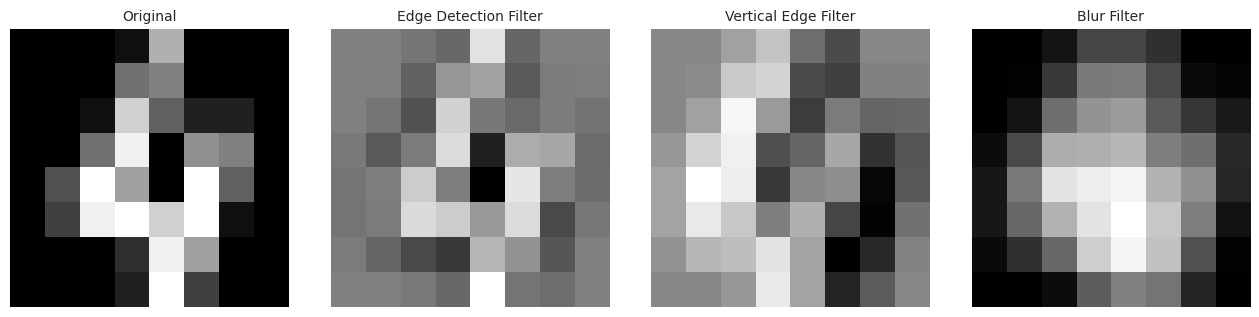

In [2]:
def conv2d(image, kernel, stride=1, padding=0):
    """A from-scratch 2D convolution (technically cross-correlation, as used in deep learning)."""
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode="constant")
    ih, iw = image.shape
    kh, kw = kernel.shape
    oh = (ih - kh) // stride + 1
    ow = (iw - kw) // stride + 1
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            region = image[i*stride:i*stride+kh, j*stride:j*stride+kw]
            out[i, j] = np.sum(region * kernel)
    return out

# Load a sample handwritten-digit image (8x8 grayscale)
digits = load_digits()
sample_image = digits.images[4]

# Classic filters
edge_kernel = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])   # edge detection
vertical_kernel = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])    # vertical edges
blur_kernel = np.ones((3, 3)) / 9                                    # smoothing/blur

edge_map = conv2d(sample_image, edge_kernel, stride=1, padding=1)
vertical_map = conv2d(sample_image, vertical_kernel, stride=1, padding=1)
blur_map = conv2d(sample_image, blur_kernel, stride=1, padding=1)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, img, title in zip(
    axes, [sample_image, edge_map, vertical_map, blur_map],
    ["Original", "Edge Detection Filter", "Vertical Edge Filter", "Blur Filter"]
):
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Stride & Padding

- **Stride** — how many pixels the filter moves each step. Stride 1 = dense scan; Stride 2 = skips
  every other position, halving the output size.
- **Padding** — adding a border of zeros around the image so the filter can be centered on edge
  pixels too, and to control output size (`"same"` padding keeps output size = input size).

Output size formula: `output = (input − kernel + 2×padding) / stride + 1`


In [3]:
for stride in [1, 2]:
    out = conv2d(sample_image, edge_kernel, stride=stride, padding=1)
    print(f"Stride {stride}: output shape = {out.shape}")

print()
for padding in [0, 1, 2]:
    out = conv2d(sample_image, edge_kernel, stride=1, padding=padding)
    print(f"Padding {padding}: output shape = {out.shape}")


Stride 1: output shape = (8, 8)
Stride 2: output shape = (4, 4)

Padding 0: output shape = (6, 6)
Padding 1: output shape = (8, 8)
Padding 2: output shape = (10, 10)


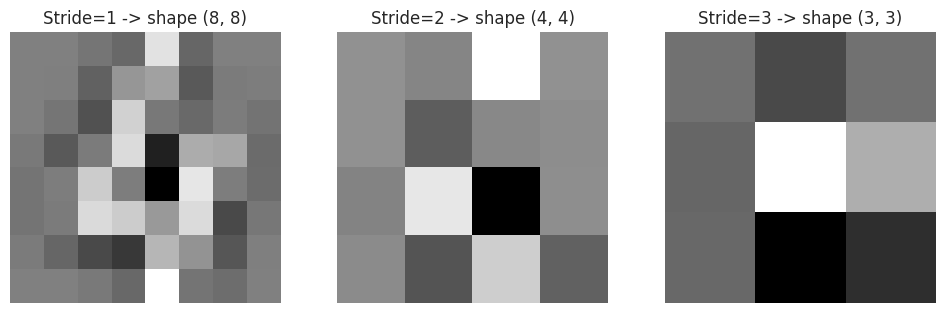

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
for ax, stride in zip(axes, [1, 2, 3]):
    out = conv2d(sample_image, edge_kernel, stride=stride, padding=1)
    ax.imshow(out, cmap="gray")
    ax.set_title(f"Stride={stride} -> shape {out.shape}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Pooling (Max & Average)

**Pooling** shrinks feature maps by summarizing small regions, which reduces computation and adds a
degree of translation invariance (small shifts in the image don't change the pooled output much).

- **Max Pooling** — keeps the strongest activation in each region (most common)
- **Average Pooling** — keeps the average activation in each region


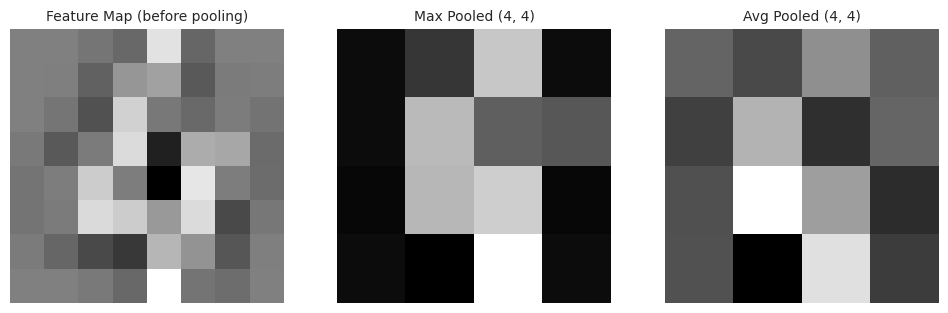

In [5]:
def max_pool(feature_map, size=2, stride=2):
    h, w = feature_map.shape
    oh, ow = (h - size)//stride + 1, (w - size)//stride + 1
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            out[i, j] = np.max(feature_map[i*stride:i*stride+size, j*stride:j*stride+size])
    return out

def avg_pool(feature_map, size=2, stride=2):
    h, w = feature_map.shape
    oh, ow = (h - size)//stride + 1, (w - size)//stride + 1
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            out[i, j] = np.mean(feature_map[i*stride:i*stride+size, j*stride:j*stride+size])
    return out

max_pooled = max_pool(edge_map, size=2, stride=2)
avg_pooled = avg_pool(edge_map, size=2, stride=2)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
for ax, img, title in zip(axes, [edge_map, max_pooled, avg_pooled],
                           ["Feature Map (before pooling)", f"Max Pooled {max_pooled.shape}", f"Avg Pooled {avg_pooled.shape}"]):
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Feature Maps — Multiple Filters

A convolutional layer applies **many filters** in parallel, each producing its own **feature map**.
Early layers might learn edge detectors; deeper layers combine these into more complex patterns
(corners, textures, shapes).


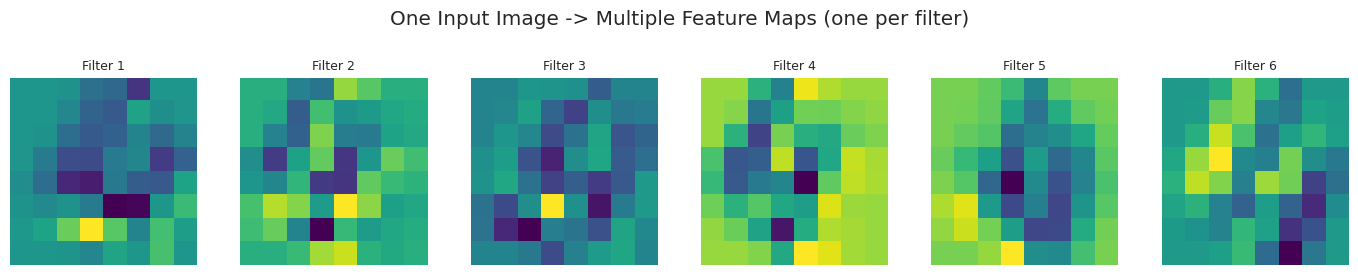

In [6]:
np.random.seed(3)
n_filters = 6
random_filters = [np.random.randn(3, 3) for _ in range(n_filters)]

fig, axes = plt.subplots(1, n_filters, figsize=(14, 2.6))
for i, (ax, kernel) in enumerate(zip(axes, random_filters)):
    fmap = conv2d(sample_image, kernel, stride=1, padding=1)
    ax.imshow(fmap, cmap="viridis")
    ax.set_title(f"Filter {i+1}", fontsize=9)
    ax.axis("off")
plt.suptitle("One Input Image -> Multiple Feature Maps (one per filter)", y=1.05)
plt.tight_layout()
plt.show()


## 6. Flatten Layer & Fully Connected Layer

After several Conv + Pool stages, the resulting 2D (or 3D, for multi-channel) feature maps are
**flattened** into a single 1D vector, which is then fed into one or more **Fully Connected (Dense)**
layers — exactly like the ANN from Day 1 — to produce the final classification.

```
Image -> [Conv -> ReLU -> Pool] x N -> Flatten -> Dense -> Dense -> Output
```


In [7]:
# Demonstrating the flatten operation
pooled_stack = np.stack([max_pool(conv2d(sample_image, k, padding=1), 2, 2) for k in random_filters])
print("Shape before flatten (filters, height, width):", pooled_stack.shape)

flat_vector = pooled_stack.flatten()
print("Shape after flatten (ready for a Dense layer):", flat_vector.shape)


Shape before flatten (filters, height, width): (6, 4, 4)
Shape after flatten (ready for a Dense layer): (96,)


---
## 7. Practice — Training a Mini CNN From Scratch

Let's put every piece together into a real, trainable CNN: **Convolution → ReLU → Max Pool → Flatten
→ Dense → Sigmoid**, trained with full backpropagation (including gradients flowing back through the
pooling and convolution layers) on real image data — classifying handwritten digits **0 vs 1**.


In [8]:
def relu(z): return np.maximum(0, z)
def relu_deriv(a): return (a > 0).astype(float)
def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

class MiniCNN:
    """A minimal, from-scratch, trainable CNN: Conv -> ReLU -> MaxPool -> Flatten -> Dense -> Sigmoid."""

    def __init__(self, n_filters=4, kernel_size=3, input_size=8):
        self.n_filters, self.k = n_filters, kernel_size
        self.filters = np.random.randn(n_filters, kernel_size, kernel_size) * np.sqrt(2/(kernel_size**2))
        self.filter_bias = np.zeros(n_filters)
        self.conv_out = input_size - kernel_size + 1
        self.pool_out = self.conv_out // 2
        self.flat_size = n_filters * self.pool_out * self.pool_out
        self.W_fc = np.random.randn(self.flat_size, 1) * np.sqrt(2/self.flat_size)
        self.b_fc = np.zeros((1, 1))

    def _conv_single(self, img, kernel):
        k, oh = self.k, self.conv_out
        out = np.zeros((oh, oh))
        for i in range(oh):
            for j in range(oh):
                out[i, j] = np.sum(img[i:i+k, j:j+k] * kernel)
        return out

    def _maxpool_single(self, fm):
        size = stride = 2
        oh = self.pool_out
        out = np.zeros((oh, oh))
        idx_i, idx_j = np.zeros((oh, oh), dtype=int), np.zeros((oh, oh), dtype=int)
        for i in range(oh):
            for j in range(oh):
                region = fm[i*stride:i*stride+size, j*stride:j*stride+size]
                out[i, j] = np.max(region)
                loc = np.unravel_index(np.argmax(region), region.shape)
                idx_i[i, j], idx_j[i, j] = i*stride+loc[0], j*stride+loc[1]
        return out, (idx_i, idx_j)

    def forward(self, X_batch):
        self.cache = []
        flat_batch = np.zeros((X_batch.shape[0], self.flat_size))
        for b, img in enumerate(X_batch):
            relu_maps, pooled_maps, pool_idxs = [], [], []
            for f in range(self.n_filters):
                cm = self._conv_single(img, self.filters[f]) + self.filter_bias[f]
                rm = relu(cm)
                pm, idx = self._maxpool_single(rm)
                relu_maps.append(rm); pooled_maps.append(pm); pool_idxs.append(idx)
            flat = np.concatenate([pm.flatten() for pm in pooled_maps])
            flat_batch[b] = flat
            self.cache.append((img, relu_maps, pool_idxs))
        self.flat_batch = flat_batch
        self.out = sigmoid(flat_batch @ self.W_fc + self.b_fc)
        return self.out

    def backward(self, y_batch, lr=0.1):
        batch_size = y_batch.shape[0]
        dz_fc = self.out - y_batch
        dW_fc = self.flat_batch.T @ dz_fc / batch_size
        db_fc = np.mean(dz_fc, axis=0, keepdims=True)
        dflat_batch = dz_fc @ self.W_fc.T

        dfilters = np.zeros_like(self.filters)
        dfilter_bias = np.zeros_like(self.filter_bias)
        k = self.k

        for b in range(batch_size):
            img, relu_maps, pool_idxs = self.cache[b]
            dpooled = dflat_batch[b].reshape(self.n_filters, self.pool_out, self.pool_out)
            for f in range(self.n_filters):
                drelu = np.zeros((self.conv_out, self.conv_out))
                idx_i, idx_j = pool_idxs[f]
                for i in range(self.pool_out):
                    for j in range(self.pool_out):
                        drelu[idx_i[i, j], idx_j[i, j]] += dpooled[f, i, j]
                dconv = drelu * relu_deriv(relu_maps[f])
                for i in range(self.conv_out):
                    for j in range(self.conv_out):
                        dfilters[f] += dconv[i, j] * img[i:i+k, j:j+k]
                dfilter_bias[f] += np.sum(dconv)

        dfilters /= batch_size
        dfilter_bias /= batch_size
        self.W_fc -= lr * dW_fc; self.b_fc -= lr * db_fc
        self.filters -= lr * dfilters; self.filter_bias -= lr * dfilter_bias

    def compute_loss(self, y):
        eps = 1e-9
        return -np.mean(y*np.log(self.out+eps) + (1-y)*np.log(1-self.out+eps))

print("MiniCNN class ready ✅")


MiniCNN class ready ✅


Train: (288, 8, 8)  Test: (72, 8, 8)


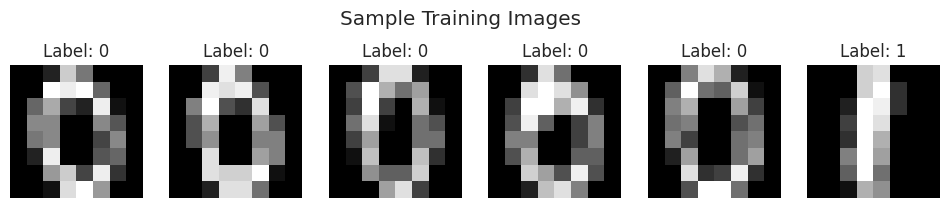

In [9]:
# Prepare data: digit 0 vs digit 1, normalized to [0, 1]
mask = (digits.target == 0) | (digits.target == 1)
X_img = digits.images[mask] / 16.0
y_img = digits.target[mask].reshape(-1, 1).astype(float)

X_train, X_test, y_train, y_test = train_test_split(X_img, y_img, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

fig, axes = plt.subplots(1, 6, figsize=(12, 2.2))
for ax, img, label in zip(axes, X_train[:6], y_train[:6]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {int(label[0])}")
    ax.axis("off")
plt.suptitle("Sample Training Images", y=1.05)
plt.show()


Epoch 0: loss=0.2689
Epoch 3: loss=0.0598
Epoch 6: loss=0.0329
Epoch 9: loss=0.0227
Epoch 12: loss=0.0172


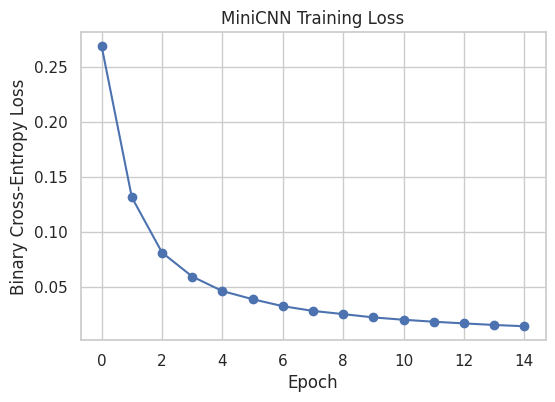

In [10]:
model = MiniCNN(n_filters=4, kernel_size=3, input_size=8)

epochs, batch_size = 15, 16
n = X_train.shape[0]
history = []

for epoch in range(epochs):
    idx = np.random.permutation(n)
    Xs, ys = X_train[idx], y_train[idx]
    for start in range(0, n, batch_size):
        Xb, yb = Xs[start:start+batch_size], ys[start:start+batch_size]
        model.forward(Xb)
        model.backward(yb, lr=0.1)
    model.forward(X_train)
    loss = model.compute_loss(y_train)
    history.append(loss)
    if epoch % 3 == 0:
        print(f"Epoch {epoch}: loss={loss:.4f}")

plt.figure()
plt.plot(history, marker="o")
plt.title("MiniCNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()


Test Accuracy: 1.000


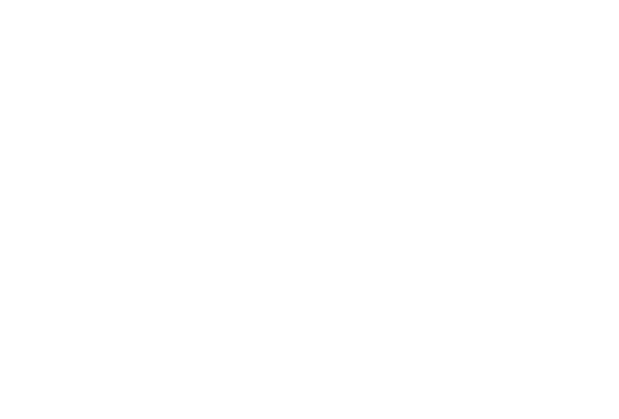

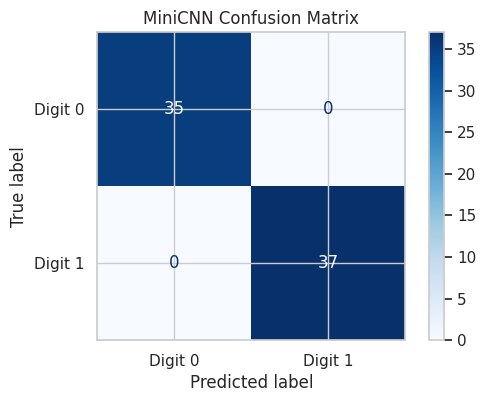

In [11]:
test_preds = model.forward(X_test)
test_pred_labels = (test_preds > 0.5).astype(int)
acc = accuracy_score(y_test, test_pred_labels)
print(f"Test Accuracy: {acc:.3f}")

cm = confusion_matrix(y_test, test_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Digit 0", "Digit 1"])
plt.figure()
disp.plot(cmap="Blues", values_format="d")
plt.title("MiniCNN Confusion Matrix")
plt.show()


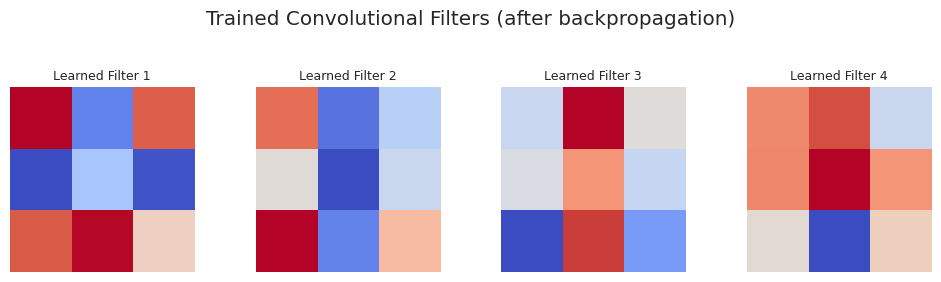

In [12]:
# Visualize what the trained filters learned to detect
fig, axes = plt.subplots(1, model.n_filters, figsize=(10, 2.6))
for i, ax in enumerate(axes):
    ax.imshow(model.filters[i], cmap="coolwarm")
    ax.set_title(f"Learned Filter {i+1}", fontsize=9)
    ax.axis("off")
plt.suptitle("Trained Convolutional Filters (after backpropagation)", y=1.08)
plt.tight_layout()
plt.show()


---
## 8. Image Preprocessing

Before feeding images to a CNN, standard preprocessing steps include:

- **Resizing** to a fixed input shape
- **Normalization** — scaling pixel values (e.g. to [0, 1] or standardized)
- **Grayscale conversion** (when color isn't needed, reduces channels from 3 to 1)
- **Center cropping** to focus on the subject


Normalized pixel range: 0.0 to 0.996078431372549


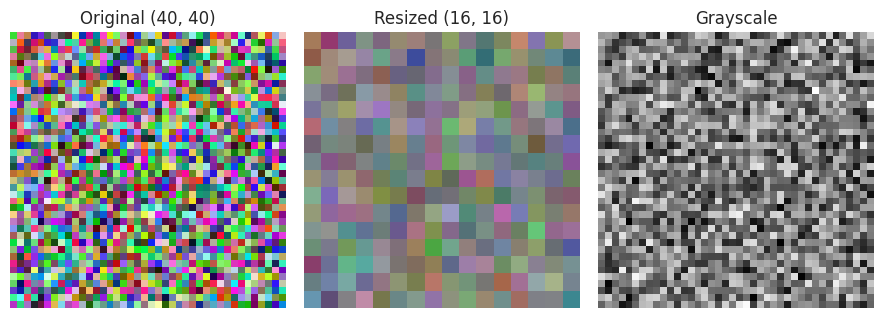

In [13]:
# Build a synthetic RGB-like image to demonstrate preprocessing steps
np.random.seed(5)
raw_image = (np.random.rand(40, 40, 3) * 255).astype(np.uint8)
pil_img = Image.fromarray(raw_image)

resized = pil_img.resize((16, 16))
grayscale = pil_img.convert("L")
normalized = np.array(pil_img) / 255.0

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
axes[0].imshow(pil_img); axes[0].set_title(f"Original {pil_img.size}")
axes[1].imshow(resized); axes[1].set_title(f"Resized {resized.size}")
axes[2].imshow(grayscale, cmap="gray"); axes[2].set_title("Grayscale")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

print("Normalized pixel range:", normalized.min(), "to", normalized.max())


## 9. Data Augmentation

**Data Augmentation** artificially expands the training set by applying label-preserving
transformations — helping the CNN generalize better and reducing overfitting, especially with
limited data.


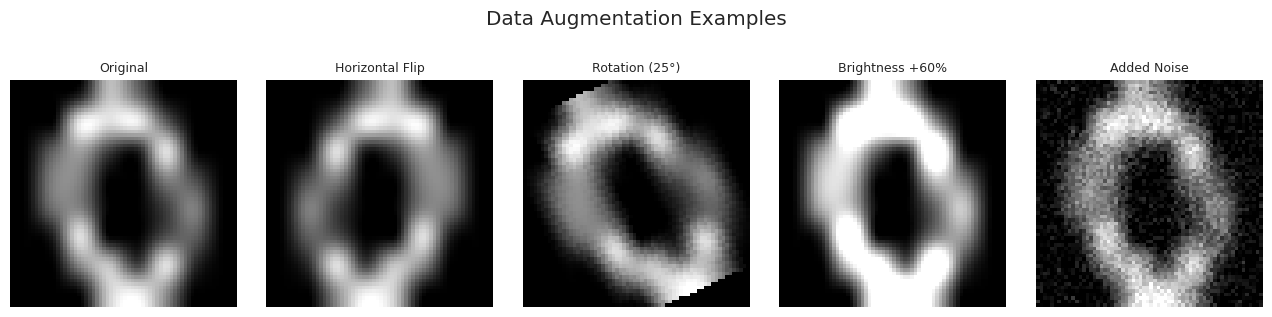

In [14]:
from PIL import ImageEnhance

original = Image.fromarray((X_train[0] * 255).astype(np.uint8)).resize((64, 64))

flipped = original.transpose(Image.FLIP_LEFT_RIGHT)
rotated = original.rotate(25)
brightened = ImageEnhance.Brightness(original).enhance(1.6)
noisy_array = np.array(original).astype(float) + np.random.normal(0, 20, np.array(original).shape)
noisy = Image.fromarray(np.clip(noisy_array, 0, 255).astype(np.uint8))

fig, axes = plt.subplots(1, 5, figsize=(13, 3))
for ax, img, title in zip(axes, [original, flipped, rotated, brightened, noisy],
                           ["Original", "Horizontal Flip", "Rotation (25°)", "Brightness +60%", "Added Noise"]):
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.suptitle("Data Augmentation Examples", y=1.05)
plt.tight_layout()
plt.show()


## 10. Transfer Learning

Training a CNN from scratch needs huge datasets and compute. **Transfer Learning** instead starts
from a model already trained on a massive dataset (e.g. ImageNet) and adapts it to a new task:

| Approach | What's trained | When to use |
|---|---|---|
| **Feature Extraction** | Only the new final classifier layer(s); the pretrained convolutional base is frozen | Small dataset, similar domain to the original |
| **Fine-Tuning** | The new classifier + some (or all) of the pretrained layers, usually at a low learning rate | Larger dataset, or task differs more from the original |

```
Pretrained CNN (frozen conv layers) -> New Dense Layer(s) -> New Task Output
                                    ↑
                     (Fine-tuning unfreezes some of these)
```

This sandbox doesn't have a downloadable pretrained network available, so here's the reference
workflow as you'd write it with Keras:

```python
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Model

base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False                      # Feature Extraction: freeze the base

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128, activation="relu")(x)
output = layers.Dense(num_classes, activation="softmax")(x)
model = Model(base_model.input, output)

# Fine-Tuning: unfreeze the top N layers and continue training at a low LR
for layer in base_model.layers[-20:]:
    layer.trainable = True
```


## 11. Popular CNN Architectures

| Architecture | Year | Key Idea |
|---|---|---|
| **LeNet-5** | 1998 | The original CNN — Conv + Pool stacks for digit recognition |
| **AlexNet** | 2012 | Deeper + ReLU + Dropout + GPU training — ignited the deep learning boom |
| **VGG** | 2014 | Very deep, uniform 3×3 conv filters stacked repeatedly |
| **GoogLeNet (Inception)** | 2014 | "Inception modules" run multiple filter sizes in parallel per layer |
| **ResNet** | 2015 | **Skip/residual connections** let networks go extremely deep (50–150+ layers) without vanishing gradients |
| **DenseNet** | 2017 | Each layer connects to *every* other layer, maximizing feature reuse |
| **EfficientNet** | 2019 | Systematically scales depth, width, and resolution together for best accuracy-per-parameter |


## 12. Computer Vision Applications

### Image Classification
Assigns a single label to an entire image — what our MiniCNN did above.

### Object Detection (YOLO basics)
Locates *and* classifies *multiple* objects in an image using **bounding boxes**. "YOLO" (You Only
Look Once) predicts all bounding boxes and class probabilities in a single forward pass, making it
extremely fast for real-time detection. Let's visualize the bounding-box concept:


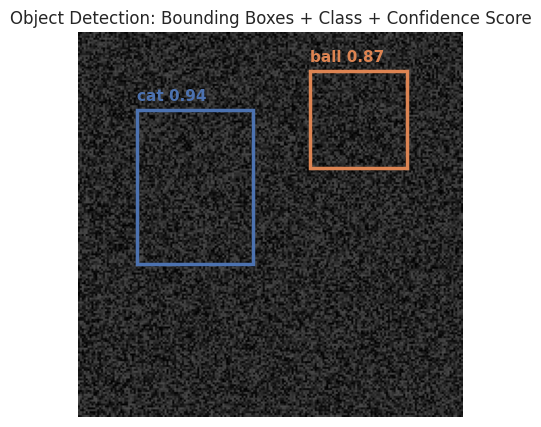

In [15]:
# Visualizing the bounding-box concept behind object detection
fig, ax = plt.subplots(figsize=(6, 5))
np.random.seed(11)
canvas = np.random.rand(200, 200) * 0.3

ax.imshow(canvas, cmap="gray", vmin=0, vmax=1)

boxes = [
    {"xy": (30, 40), "w": 60, "h": 80, "label": "cat 0.94", "color": "#4C72B0"},
    {"xy": (120, 20), "w": 50, "h": 50, "label": "ball 0.87", "color": "#DD8452"},
]
for box in boxes:
    rect = plt.Rectangle(box["xy"], box["w"], box["h"], fill=False, edgecolor=box["color"], linewidth=2.5)
    ax.add_patch(rect)
    ax.text(box["xy"][0], box["xy"][1]-5, box["label"], color=box["color"], fontsize=11, fontweight="bold")

ax.set_title("Object Detection: Bounding Boxes + Class + Confidence Score")
ax.axis("off")
plt.show()


### Semantic Segmentation (basic idea)
Instead of a box, segmentation classifies **every single pixel** into a category, producing a
pixel-level mask — used in medical imaging, self-driving cars (road/lane/pedestrian masks), and
photo editing tools.


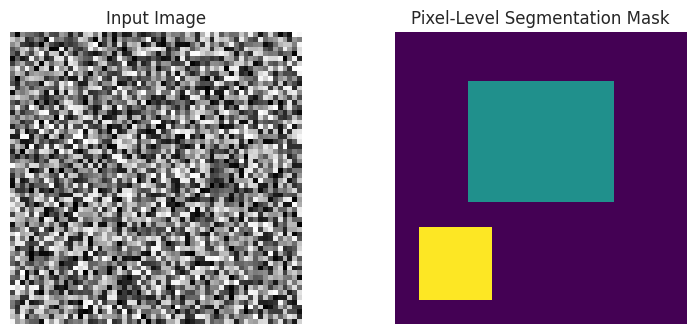

In [16]:
# Visualizing the segmentation-mask concept
np.random.seed(2)
mask_demo = np.zeros((60, 60))
mask_demo[10:35, 15:45] = 1   # "object" region
mask_demo[40:55, 5:20] = 2    # a second "object" region

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(np.random.rand(60, 60), cmap="gray")
axes[0].set_title("Input Image")
axes[1].imshow(mask_demo, cmap="viridis")
axes[1].set_title("Pixel-Level Segmentation Mask")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()


### Practice Note — MNIST / CIFAR-10 with Real Frameworks

This notebook trained a genuine from-scratch CNN on digit images to make every gradient computation
transparent. In a GPU-enabled environment with TensorFlow/PyTorch installed, the equivalent MNIST/CIFAR-10
practice would look like this:

```python
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(X_train, y_train, epochs=10, validation_split=0.1)
```


---
## 🔑 Key Takeaways

- CNNs preserve spatial structure and share weights via **filters/kernels**, unlike fully connected networks.
- **Stride** controls how far a filter moves each step; **padding** controls output size and edge coverage.
- **Pooling** (max/average) shrinks feature maps and adds translation invariance.
- A CNN applies many filters per layer, producing multiple **feature maps** that capture different patterns.
- After Conv+Pool stages, a **Flatten** layer feeds into **Fully Connected** layers for the final prediction.
- We trained a real CNN from scratch (forward + backprop through conv and pooling layers) and it reached strong accuracy on real image data.
- **Image preprocessing** (resize, normalize, grayscale) and **data augmentation** (flips, rotation, brightness, noise) improve robustness and generalization.
- **Transfer Learning** (feature extraction vs fine-tuning) lets you leverage huge pretrained models instead of training from scratch.
- Landmark architectures — **LeNet, AlexNet, VGG, GoogLeNet, ResNet, DenseNet, EfficientNet** — each solved a specific bottleneck in going deeper and more efficient.
- Computer vision tasks build on the same CNN backbone: **Classification** (1 label), **Object Detection** (boxes + labels), **Segmentation** (per-pixel labels).

**Next up (Module 5, Day 3):** Sequential Models & Advanced Deep Learning — RNNs, LSTMs, Attention, Transformers, and Generative Models.
